In [ ]:
import warnings
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import shap
from transformers import AutoTokenizer, RobertaModel, AutoConfig
import pathlib

warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
# Notebook lives in notebooks/, project root is one level up
PROJECT_ROOT = pathlib.Path("../").resolve()

DATA_FILE  = str(PROJECT_ROOT / "data/final.parquet")
DELTA_DIR  = str(PROJECT_ROOT / "out/delta_binary_mental_health_manual")
MODEL_NAME = "mental/mental-roberta-base"

print(f"Project root: {PROJECT_ROOT}")
print(f"Delta model:  {DELTA_DIR}")

# --- BINARY AdvancedDeltaModel CLASS DEFINITION ---
class AdvancedDeltaModel(nn.Module):
    def __init__(self, base_name="mental/mental-roberta-base", num_labels=2, num_features=50, dropout_rate=0.3):
        super().__init__()
        self.num_labels = num_labels
        self.base = RobertaModel.from_pretrained(base_name)
        hidden_size = self.base.config.hidden_size
        self.feature_encoder = nn.Sequential(
            nn.Linear(num_features, 64), nn.ReLU(), nn.Dropout(dropout_rate)
        )
        self.fusion_gate = nn.Sequential(
            nn.Linear(hidden_size + 64, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.Sigmoid()
        )
        self.classifier = nn.Linear(hidden_size + 64, num_labels)

    def forward(self, input_ids=None, attention_mask=None, delta=None, labels=None):
        outputs = self.base(input_ids=input_ids, attention_mask=attention_mask)
        text_features = outputs.last_hidden_state[:, 0]
        behavioral_features_encoded = self.feature_encoder(delta.float())
        gate_input = torch.cat([text_features, behavioral_features_encoded], dim=1)
        gate_values = self.fusion_gate(gate_input)
        gated_behavioral_features = behavioral_features_encoded * gate_values
        final_combined_features = torch.cat([text_features, gated_behavioral_features], dim=1)
        logits = self.classifier(final_combined_features)
        return logits

print("Setup complete.")


In [3]:
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Read config directly — no model_type key so AutoConfig won't work
with open(pathlib.Path(DELTA_DIR) / "config.json") as f:
    delta_cfg = json.load(f)

base_name     = delta_cfg["_name_or_path"]
num_labels    = delta_cfg["num_labels"]
num_features  = delta_cfg["custom_num_features"]
dropout_rate  = delta_cfg["custom_dropout_rate"]

print(f"Config: base={base_name}, labels={num_labels}, features={num_features}, dropout={dropout_rate}")

# Instantiate and load the binary model
delta_model = AdvancedDeltaModel(
    base_name=base_name,
    num_labels=num_labels,
    num_features=num_features,
    dropout_rate=dropout_rate
).to(device)

weights_path = pathlib.Path(DELTA_DIR) / "pytorch_model.bin"
state_dict = torch.load(weights_path, map_location=device)
delta_model.load_state_dict(state_dict)
delta_model.eval()

# Load tokenizer and data
tokenizer = AutoTokenizer.from_pretrained(base_name)
df = pd.read_parquet(DATA_FILE)

# Create binary labels: 0=control, 1=any mental health condition
LABEL_MAP = {"control": 0, "depression": 1, "anxiety": 2, "bipolar": 3}
df['binary_label'] = df['label'].apply(lambda x: 0 if x == LABEL_MAP['control'] else 1)

test_df = df[df['split'] == 'test'].reset_index(drop=True)

# Get the feature list using binary labels (matching training)
from sklearn.feature_selection import mutual_info_classif
def get_feature_list(df, n_features):
    exclude_cols = ['tweet_id', 'user_id', 'text', 'label', 'label_name', 'split', 'created', 'binary_label']
    feature_cols = [c for c in df.columns if c not in exclude_cols and df[c].dtype in ['float64', 'int64']]
    if not feature_cols: return []
    train_df = df[df['split'] == 'train']
    train_y = train_df['binary_label'].values
    X = train_df[feature_cols].fillna(0).values
    mi_scores = mutual_info_classif(X, train_y, random_state=42)
    feature_scores = pd.DataFrame({'feature': feature_cols, 'score': mi_scores}).sort_values('score', ascending=False)
    return feature_scores.head(n_features)['feature'].tolist()

selected_features = get_feature_list(df, n_features=num_features)

class_names = ['control', 'mental_health']
print(f"Model loaded. Classes: {class_names}")
print(f"Selected {len(selected_features)} features: {selected_features}")


Config: base=mental/mental-roberta-base, labels=2, features=28, dropout=0.4


Some weights of RobertaModel were not initialized from the model checkpoint at mental/mental-roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded. Classes: ['control', 'mental_health']
Selected 28 features: ['tpd_3d_dev', 'tpd_7d_dev', 'sent_compound_dev', 'tpd_14d_dev', 'len_dev', 'tpd_30d_dev', 'sent_compound_z', 'emotion_volatility_10tw', 'self_focus', 'burst_posting', 'late_night', 'polarity_shift', 'circadian_deviation', 'silence_period', 'tpd_3d', 'tpd_7d', 'neg', 'tpd_14d', 'len_val', 'compound', 'pos', 'exclamation_count', 'neu', 'tpd_30d', 'len_z', 'isolation_score', 'mention_count', 'anomaly_score']


In [15]:
# --- Find Multiple High-Confidence Predictions (batched, early stop) ---

CONFIDENCE_THRESHOLD = 0.85   # minimum softmax probability to qualify
MAX_EXAMPLES         = 20     # how many to collect for SHAP analysis
SCAN_POOL            = 200    # stop after collecting this many candidates
BATCH_SIZE           = 128    # tweets per forward pass
target_label         = 1      # 1 = mental_health

# Shuffle so we get a diverse spread, not just the first N rows
mh_df = test_df[test_df['binary_label'] == target_label].sample(frac=1, random_state=42)
print(f"Scanning up to {len(mh_df)} mental_health rows (stops early once {SCAN_POOL} candidates found)...")

candidates = []  # (confidence, original test_df index)

for batch_start in range(0, len(mh_df), BATCH_SIZE):
    batch = mh_df.iloc[batch_start : batch_start + BATCH_SIZE]

    tokenized = tokenizer(
        batch['text'].tolist(),
        return_tensors='pt', truncation=True,
        padding='max_length', max_length=128
    )
    delta_tensor = torch.tensor(
        batch[selected_features].fillna(0).values, dtype=torch.float32
    )
    with torch.no_grad():
        logits = delta_model(
            input_ids=tokenized['input_ids'].to(device),
            attention_mask=tokenized['attention_mask'].to(device),
            delta=delta_tensor.to(device)
        )
        probas = torch.softmax(logits, dim=1).cpu().numpy()

    preds = probas.argmax(axis=1)
    confs = probas[np.arange(len(batch)), preds]

    for i, (pred, conf) in enumerate(zip(preds, confs)):
        if pred == target_label and conf >= CONFIDENCE_THRESHOLD:
            candidates.append((float(conf), int(batch.index[i])))

    if len(candidates) >= SCAN_POOL:
        print(f"  Early stop — found {len(candidates)} candidates after {batch_start + len(batch)} rows")
        break

# Sort by confidence descending, keep top MAX_EXAMPLES
candidates.sort(reverse=True)
candidates = candidates[:MAX_EXAMPLES]

if candidates:
    print(f"\nTop {len(candidates)} examples by confidence:")
    for rank, (conf, idx) in enumerate(candidates, 1):
        print(f"  #{rank:2d}  idx={idx:5d}  confidence={conf:.1%}  "
              f"text={test_df.loc[idx,'text'][:60]!r}")
    explain_indices = [idx  for _, idx  in candidates]
    explain_confs   = [conf for conf, _ in candidates]
else:
    explain_indices = []
    print("No examples found. Try lowering CONFIDENCE_THRESHOLD.")


Scanning up to 63203 mental_health rows (stops early once 200 candidates found)...
  Early stop — found 244 candidates after 512 rows

Top 20 examples by confidence:
  # 1  idx=15918  confidence=99.9%  text="If you're a United States Senator, no matter your party toda"
  # 2  idx=92723  confidence=99.9%  text='Because every Sunday needs an #inspirationalquote . 🌻🩷💜  Rem'
  # 3  idx=69752  confidence=99.9%  text='I’m not worried Bolton came in like WWE wrestlers and we did'
  # 4  idx=23467  confidence=99.9%  text='💡 Are you struggling to identify patients with traditional t'
  # 5  idx=45048  confidence=99.9%  text="See!!??? ..& some of y'all wonder why u don't get invited ov"
  # 6  idx=17994  confidence=99.9%  text='Engagement grows when people come together around a shared b'
  # 7  idx= 5330  confidence=99.9%  text="I've been sober for 19 years today. If I hadn't quit when I "
  # 8  idx=23423  confidence=99.9%  text='Day 2 of #DIA2024 has begun!  Meet us at booth #2309 for #AI'
  

In [16]:
# Prediction Function for SHAP (Binary Model)

def shap_predict_single_class(texts_and_features, class_index):
    token_ids = texts_and_features[:, :128].astype(int)
    delta_features = texts_and_features[:, 128:]
    token_ids_tensor = torch.tensor(token_ids).to(device)
    delta_tensor = torch.tensor(delta_features.astype(np.float32), dtype=torch.float32).to(device)
    attention_mask_tensor = (token_ids_tensor != tokenizer.pad_token_id).long()
    with torch.no_grad():
        logits = delta_model(input_ids=token_ids_tensor, attention_mask=attention_mask_tensor, delta=delta_tensor)
        # binary model returns logits directly
    probas = torch.softmax(logits, dim=-1).cpu().numpy()
    return probas[:, class_index]

print("SHAP single-class prediction function is ready.")


SHAP single-class prediction function is ready.


Computing SHAP values for 20 examples...

  [1/20] idx=15918  conf=99.9%  done
  [2/20] idx=92723  conf=99.9%  done
  [3/20] idx=69752  conf=99.9%  done
  [4/20] idx=23467  conf=99.9%  done
  [5/20] idx=45048  conf=99.9%  done
  [6/20] idx=17994  conf=99.9%  done
  [7/20] idx=5330  conf=99.9%  done
  [8/20] idx=23423  conf=99.9%  done
  [9/20] idx=23553  conf=99.9%  done
  [10/20] idx=48638  conf=99.9%  done
  [11/20] idx=45055  conf=99.9%  done
  [12/20] idx=23453  conf=99.9%  done
  [13/20] idx=45643  conf=99.9%  done
  [14/20] idx=12975  conf=99.8%  done
  [15/20] idx=48794  conf=99.8%  done
  [16/20] idx=48687  conf=99.8%  done
  [17/20] idx=7547  conf=99.8%  done
  [18/20] idx=107431  conf=99.8%  done
  [19/20] idx=11239  conf=99.8%  done
  [20/20] idx=17903  conf=99.8%  done

  AGGREGATED SHAP — top features across 20 examples


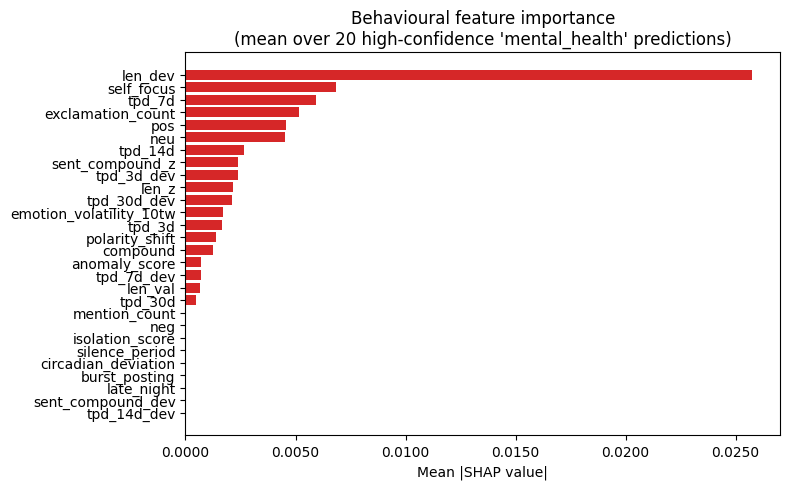

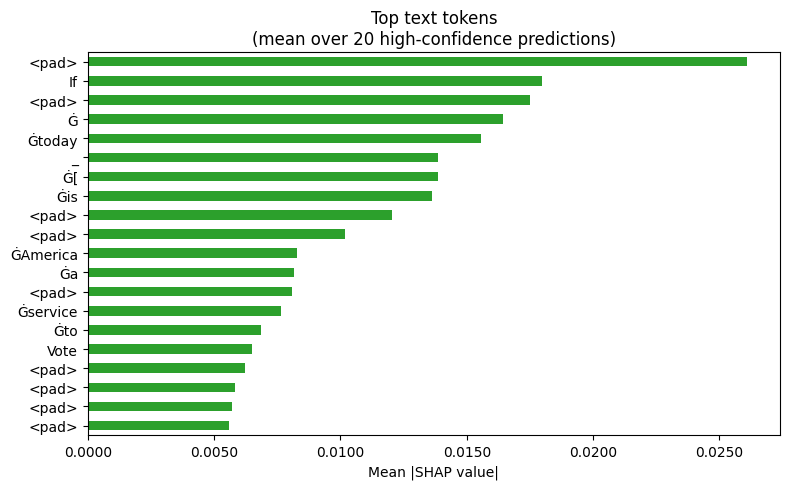


Top 10 behavioural features by mean |SHAP|:
len_dev              0.025730
self_focus           0.006850
tpd_7d               0.005928
exclamation_count    0.005143
pos                  0.004549
neu                  0.004512
tpd_14d              0.002650
sent_compound_z      0.002395
tpd_3d_dev           0.002387
len_z                0.002158


In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

if not explain_indices:
    print("No examples to explain.")
else:
    # --- Build background once ---
    background_data = test_df.sample(50, random_state=42)
    bg_ids = tokenizer(
        background_data['text'].tolist(),
        return_tensors='np', truncation=True, padding='max_length', max_length=128
    )['input_ids']
    bg_deltas = background_data[selected_features].fillna(0).values
    shap_background = shap.kmeans(np.hstack([bg_ids, bg_deltas]), 10)

    prediction_function = lambda x: shap_predict_single_class(x, class_index=target_label)
    explainer = shap.KernelExplainer(prediction_function, shap_background)

    all_feature_names = None
    all_shap_values   = []   # one row per example
    all_shap_data     = []   # raw feature values per example

    print(f"Computing SHAP values for {len(explain_indices)} examples...\n")
    for i, idx in enumerate(explain_indices):
        text = test_df.loc[idx, 'text']
        tok  = tokenizer(text, return_tensors='np', truncation=True,
                         padding='max_length', max_length=128)
        input_ids = tok['input_ids'][0]
        delta_np  = test_df.loc[idx, selected_features].fillna(0).values.reshape(1, -1)
        shap_input = np.hstack([input_ids.reshape(1, -1), delta_np])[0]

        if all_feature_names is None:
            tokens = tokenizer.convert_ids_to_tokens(input_ids)
            all_feature_names = tokens + selected_features

        sv = explainer.shap_values(shap_input, nsamples=128)
        all_shap_values.append(sv)
        all_shap_data.append(shap_input)
        print(f"  [{i+1}/{len(explain_indices)}] idx={idx}  conf={explain_confs[i]:.1%}  done")

    # Stack: shape (n_examples, n_features)
    shap_matrix = np.vstack(all_shap_values)   # (N, 128+28)
    data_matrix = np.vstack(all_shap_data)      # (N, 128+28)
    mean_abs    = np.abs(shap_matrix).mean(axis=0)

    n_tokens = 128
    token_importance   = pd.Series(mean_abs[:n_tokens],  index=all_feature_names[:n_tokens])
    feature_importance = pd.Series(mean_abs[n_tokens:],  index=selected_features)

    print(f"\n{'='*55}")
    print(f"  AGGREGATED SHAP — top features across {len(explain_indices)} examples")
    print(f"{'='*55}")

    # --- Plot 1: Behavioural (delta) features — beeswarm-style bar ---
    fig, ax = plt.subplots(figsize=(8, 5))
    feat_df = feature_importance.sort_values(ascending=True)
    colors  = ['#d62728' if v > 0 else '#1f77b4'
               for v in shap_matrix[:, n_tokens:].mean(axis=0)[feat_df.index.map(
                   lambda f: selected_features.index(f))]]
    ax.barh(feat_df.index, feat_df.values, color='#d62728')
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_title(f"Behavioural feature importance\n(mean over {len(explain_indices)} high-confidence '{class_names[target_label]}' predictions)")
    ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.4f'))
    plt.tight_layout()
    plt.show()

    # --- Plot 2: Top text tokens ---
    top_tokens = token_importance.sort_values(ascending=False).head(20)
    fig, ax = plt.subplots(figsize=(8, 5))
    top_tokens.sort_values(ascending=True).plot.barh(ax=ax, color='#2ca02c')
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_title(f"Top text tokens\n(mean over {len(explain_indices)} high-confidence predictions)")
    ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.4f'))
    plt.tight_layout()
    plt.show()

    # --- Summary table ---
    print("\nTop 10 behavioural features by mean |SHAP|:")
    print(feature_importance.sort_values(ascending=False).head(10).to_string())
